# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Adam Elhabian )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt

import seaborn as sns

%matplotlib inline

In [2]:
# Load my dataset using pandas Dataframe

df=pd.read_csv('../data/raw/fordgobike-tripdataFor201902.csv')
print("dataset loaded Successfully")

dataset loaded Successfully


In [3]:
# here we make overview in high-level for data shape and composition

print("Num of rows: ",df.shape[0])
print("Num of columns: ",df.shape[1])
print("Dataset shape : ",df.shape)
print("columns Name : ",df.columns)

Num of rows:  183416
Num of columns:  16
Dataset shape :  (183416, 16)
columns Name :  Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')


In [4]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [5]:
## check each var  datatype 
df.dtypes


duration_sec                 int64
start_time                  object
end_time                    object
start_station_id           float64
start_station_name          object
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name            object
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                   object
member_birth_year          float64
member_gender               object
bike_share_for_all_trip     object
dtype: object

In [6]:
numric_cols=['duration_sec']

cat_cols=['user_type','member_gender','bike_share_for_all_trip']
# start time and end time have error in range 
datatime_cols=['start_time','end_time']
id_cols=['start_station_id','end_station_id','bike_id']
str_cols=['start_station_name','end_station_name']

In [7]:
df[cat_cols]=df[cat_cols].astype('category')
df[str_cols]=df[str_cols].astype('string')
df[id_cols]=df[id_cols].astype('string')


# i can't do this because start time and end time have error in range 
# df[datatime_cols]=df[datatime_cols].apply(pd.to_datetime)
df.dtypes

duration_sec                        int64
start_time                         object
end_time                           object
start_station_id           string[python]
start_station_name         string[python]
start_station_latitude            float64
start_station_longitude           float64
end_station_id             string[python]
end_station_name           string[python]
end_station_latitude              float64
end_station_longitude             float64
bike_id                    string[python]
user_type                        category
member_birth_year                 float64
member_gender                    category
bike_share_for_all_trip          category
dtype: object

In [8]:
## start and end time are dateformat  minites:seconds
## so i will make start time 00:minites:seconds and make end time = duration_sec + start time 

df['start_time'] = pd.to_timedelta(
    '00:' + df['start_time'].astype(str)
).round('s')

df['end_time'] = pd.to_timedelta(
    '00:' + df['end_time'].astype(str)
).round('s')

df['calc_end_time'] = (
    df['start_time'] +
    pd.to_timedelta(df['duration_sec'].round(), unit='s')
).round('s')


# before this algorithm my time is in  num days hours:minites:seconds but i want to make it hours:minites:seconds only so i want to make num of dayes be hours+=num*24

# df['start_time'] = df['start_time'].dt.total_seconds().round().astype(int).map(
#     lambda x: f'{x // 3600:02d}:{(x % 3600) // 60:02d}:{x % 60:02d}'
# )

# df['end_time'] = df['end_time'].dt.total_seconds().round().astype(int).map(
#     lambda x: f'{x // 3600:02d}:{(x % 3600) // 60:02d}:{x % 60:02d}'
# )

# df['calc_end_time'] = df['calc_end_time'].dt.total_seconds().round().astype(int).map(
#     lambda x: f'{x // 3600:02d}:{(x % 3600) // 60:02d}:{x % 60:02d}'
# )

df.dtypes

duration_sec                         int64
start_time                 timedelta64[ns]
end_time                   timedelta64[ns]
start_station_id            string[python]
start_station_name          string[python]
start_station_latitude             float64
start_station_longitude            float64
end_station_id              string[python]
end_station_name            string[python]
end_station_latitude               float64
end_station_longitude              float64
bike_id                     string[python]
user_type                         category
member_birth_year                  float64
member_gender                     category
bike_share_for_all_trip           category
calc_end_time              timedelta64[ns]
dtype: object

In [9]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,calc_end_time
0,52185,0 days 00:32:10.100000,0 days 00:01:56,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,0 days 15:01:55.100000
1,42521,0 days 00:53:21.800000,0 days 00:42:03.100000,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,0 days 12:42:02.800000
2,61854,0 days 00:13:13.200000,0 days 00:24:08.100000,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,0 days 17:24:07.200000
3,36490,0 days 00:54:26,0 days 00:02:36.800000,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,0 days 11:02:36
4,1585,0 days 00:54:18.500000,0 days 00:20:44.100000,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,0 days 01:20:43.500000


In [10]:
df['end_time']=df['calc_end_time']
df.drop(columns=['calc_end_time'],inplace=True)
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,0 days 00:32:10.100000,0 days 15:01:55.100000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,0 days 00:53:21.800000,0 days 12:42:02.800000,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,0 days 00:13:13.200000,0 days 17:24:07.200000,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,0 days 00:54:26,0 days 11:02:36,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,0 days 00:54:18.500000,0 days 01:20:43.500000,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [11]:
## I display 15 rows to understand the content values more 

display(pd.concat([df.head(),df.tail()]))

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,0 days 00:32:10.100000,0 days 15:01:55.100000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,0 days 00:53:21.800000,0 days 12:42:02.800000,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,0 days 00:13:13.200000,0 days 17:24:07.200000,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,0 days 00:54:26,0 days 11:02:36,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,0 days 00:54:18.500000,0 days 01:20:43.500000,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
183411,271,0 days 00:00:20.600000,0 days 00:04:51.600000,24.0,Spear St at Folsom St,37.789677,-122.390428,37.0,2nd St at Folsom St,37.785000,-122.395936,1057,Subscriber,1989.0,Male,No
183412,313,0 days 00:05:34.700000,0 days 00:10:47.700000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,-122.392741,4960,Subscriber,1984.0,Male,No
183413,141,0 days 00:06:05.500000,0 days 00:08:26.500000,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,-121.908586,3824,Subscriber,1990.0,Male,Yes
183414,139,0 days 00:05:34.400000,0 days 00:07:53.400000,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,-122.275698,5095,Subscriber,1988.0,Male,No
183415,271,0 days 00:00:20.600000,0 days 00:04:51.600000,24.0,Spear St at Folsom St,37.789677,-122.390428,37.0,2nd St at Folsom St,37.785000,-122.395936,1057,Subscriber,1989.0,Male,No


In [12]:
# descriptive statistics for numeric variables
df.describe()


,duration_sec,start_time,end_time,start_station_latitude,start_station_longitude,end_station_latitude,end_station_longitude,member_birth_year
count,183416.000000,183416,183416,183416.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,0 days 00:29:57.014513455,0 days 00:42:03.081824922,37.771221,-122.352661,37.771425,-122.352247,1984.806504
std,1794.371831,0 days 00:17:22.280020821,0 days 00:34:32.082130743,0.099586,0.117100,0.099494,0.116677,10.116589
min,61.000000,0 days 00:00:00,0 days 00:01:22.900000,37.317298,-122.453705,37.317298,-122.453705,1878.000000
25%,325.000000,0 days 00:14:39.600000,0 days 00:24:56.400000,37.770083,-122.412408,37.770407,-122.411726,1980.000000
50%,514.000000,0 days 00:29:58.200000,0 days 00:40:45.100000,37.780760,-122.398285,37.781010,-122.398279,1987.000000
75%,796.000000,0 days 00:45:05.100000,0 days 00:55:47.400000,37.797280,-122.286533,37.797320,-122.288045,1992.000000
max,85444.000000,0 days 00:59:59.900000,1 days 00:43:59.100000,37.880222,-121.874119,37.880222,-121.874119,2001.000000


> ### What is the structure of your dataset?

- The structure of the dataset contains **..16... columns** and **...183416.... rows**.

- Most variables are **...numeric and categorical...** in nature, and here is the **dtypes summary**:

  - object (7)
  - integer (2)
  - float (7)

> ### What are the main interesting features in the dataset?

**We got three main feature areas which are:**

- start_time,end_time : to detect duration 

- start,end stationsid  : with start and end time i can detect the availabilty of bikes in each station

- user behaviours : i can use birth_year , gender to detect behaviours 

> ### What features in the dataset supported my investigation for these interesting features?

- **Trip Duration:** `duration_sec`, `start_time`, `end_time`

- **Station Usage:** `start_station_id`, `start_station_name`, `end_station_id`, `end_station_name`

- **Geographical Analysis:** `start_station_latitude`, `start_station_longitude`, `end_station_latitude`, `end_station_longitude`

- **User Behavior:** `user_type`, `member_gender`, `member_birth_year`, `bike_share_for_all_trip`

- **Bike Usage:** `bike_id`


##  More Exploring ideas to begin my investigation

In [13]:
#This code for describing statistical data ideas in a more organized and readable table
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [14]:
#yOUR CODES
MV_df=pd.DataFrame({'missing values count':(df.isnull().sum()[df.isnull().sum()>0])
                    ,'ratio':((df.isnull().sum()[df.isnull().sum()>0]/df.shape[0])*100).round(2)}).T
display(MV_df)

,start_station_id,start_station_name,end_station_id,end_station_name,member_birth_year,member_gender
missing values count,197.00,197.00,197.00,197.00,8265.00,8265.00
ratio,0.11,0.11,0.11,0.11,4.51,4.51




> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with ........... for numeric and ......for categorical

In [15]:
# 0.11 percentage is very small so i decide to delete these raws
df = df.dropna(subset=[
    'start_station_id',
    'start_station_name',
    'end_station_id',
    'end_station_name'
])

df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name            0
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name              0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8263
member_gender              8263
bike_share_for_all_trip       0
dtype: int64

In [16]:
# i want to understand the reason of  birth year and gender missing values

df['birth_year_missing'] = df['member_birth_year'].isna()
df['gender_missing'] = df['member_gender'].isna()
df[['birth_year_missing','gender_missing']]=df[['birth_year_missing','gender_missing']].astype('category')
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,birth_year_missing,gender_missing
0,52185,0 days 00:32:10.100000,0 days 15:01:55.100000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,False,False
1,42521,0 days 00:53:21.800000,0 days 12:42:02.800000,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,True,True
2,61854,0 days 00:13:13.200000,0 days 17:24:07.200000,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,False,False
3,36490,0 days 00:54:26,0 days 11:02:36,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,False,False
4,1585,0 days 00:54:18.500000,0 days 01:20:43.500000,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,False,False


In [17]:
# i want to add feature age to facilate relation between it and anther features
from datetime import datetime

current_year = datetime.now().year


df['age']=current_year-df['member_birth_year']
df.head()


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,birth_year_missing,gender_missing,age
0,52185,0 days 00:32:10.100000,0 days 15:01:55.100000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,False,False,42.0
1,42521,0 days 00:53:21.800000,0 days 12:42:02.800000,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,True,True,NaN
2,61854,0 days 00:13:13.200000,0 days 17:24:07.200000,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,False,False,54.0
3,36490,0 days 00:54:26,0 days 11:02:36,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,False,False,37.0
4,1585,0 days 00:54:18.500000,0 days 01:20:43.500000,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,False,False,52.0


In [18]:
from datetime import datetime

current_year = datetime.now().year

df['age'] = current_year - df['member_birth_year']

In [19]:
df['age_missing']=df['age'].isna()

### i want to find the relation between missing values in member_birth_year , member_gender and other features

In [20]:
# problem come from bike_share_for_all_trip equall no
df[df['age_missing']]['bike_share_for_all_trip'].value_counts()

bike_share_for_all_trip
No     8263
Yes       0
Name: count, dtype: int64

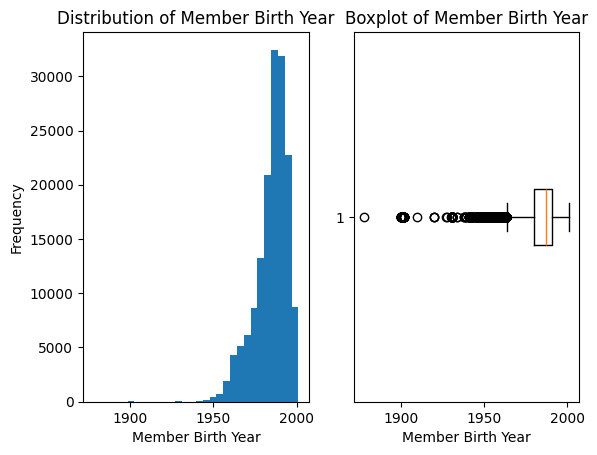

In [21]:


plt.subplot(1,2,1)
plt.hist(df[df['bike_share_for_all_trip']=='No']['member_birth_year'].dropna(), bins=30)
plt.xlabel('Member Birth Year')
plt.ylabel('Frequency')
plt.title('Distribution of Member Birth Year')


plt.subplot(1,2,2)
plt.boxplot(df[df['bike_share_for_all_trip']=='No']['member_birth_year'].dropna(), vert=False)
plt.xlabel('Member Birth Year')
plt.title('Boxplot of Member Birth Year')



plt.show()

In [22]:
print(df['member_birth_year'].isnull().sum())

df['member_birth_year'] = df['member_birth_year'].fillna(
    df[df['bike_share_for_all_trip']=='No']['member_birth_year'].median()
)
print(df['member_birth_year'].isnull().sum())

8263
0


<Axes: xlabel='member_gender', ylabel='count'>

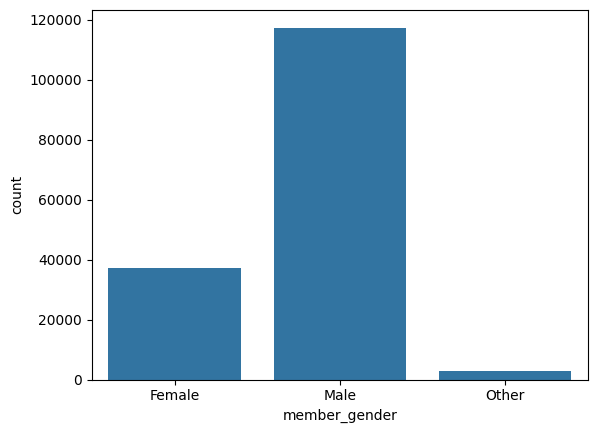

In [23]:
sns.countplot(x=df[df['bike_share_for_all_trip']=='No']['member_gender'],data=df)

In [24]:
print(df['member_gender'].isnull().sum())
df['member_gender']=df['member_gender'].fillna(df[df['bike_share_for_all_trip']=='No']['member_gender'].mode()[0])
print(df['member_gender'].isnull().sum())


8263
0


Text(0.5, 1.0, 'Boxplot of Member Birth Year')

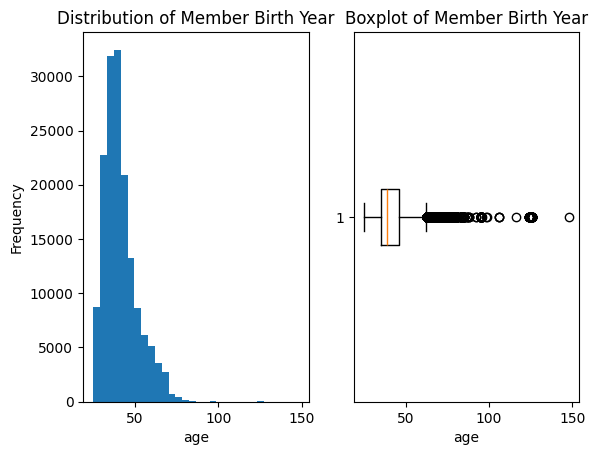

In [25]:
plt.subplot(1,2,1)
plt.hist(df[df['bike_share_for_all_trip']=='No']['age'].dropna(), bins=30)
plt.xlabel('age')
plt.ylabel('Frequency')
plt.title('Distribution of Member Birth Year')


plt.subplot(1,2,2)
plt.boxplot(df[df['bike_share_for_all_trip']=='No']['age'].dropna(), vert=False)
plt.xlabel('age')
plt.title('Boxplot of Member Birth Year')

In [26]:
print(df['age'].isnull().sum())

df['age'] = df['age'].fillna(
    df[df['bike_share_for_all_trip']=='No']['age'].median()
)
print(df['age'].isnull().sum())

8263
0


In [27]:
df.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
birth_year_missing         0
gender_missing             0
age                        0
age_missing                0
dtype: int64

> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [28]:
##  check duplicate in dataset
df.duplicated().sum()



np.int64(4)

In [29]:
df = df.drop_duplicates()

> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [30]:
### check the category columns that included object
df.dtypes


duration_sec                         int64
start_time                 timedelta64[ns]
end_time                   timedelta64[ns]
start_station_id            string[python]
start_station_name          string[python]
start_station_latitude             float64
start_station_longitude            float64
end_station_id              string[python]
end_station_name            string[python]
end_station_latitude               float64
end_station_longitude              float64
bike_id                     string[python]
user_type                         category
member_birth_year                  float64
member_gender                     category
bike_share_for_all_trip           category
birth_year_missing                category
gender_missing                    category
age                                float64
age_missing                           bool
dtype: object

In [31]:
df.nunique()

duration_sec                4749
start_time                 35780
end_time                   45955
start_station_id             329
start_station_name           329
start_station_latitude       329
start_station_longitude      329
end_station_id               329
end_station_name             329
end_station_latitude         329
end_station_longitude        329
bike_id                     4618
user_type                      2
member_birth_year             75
member_gender                  3
bike_share_for_all_trip        2
birth_year_missing             2
gender_missing                 2
age                           75
age_missing                    2
dtype: int64

 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [32]:
## check your work 

df[['member_gender','user_type','member_birth_year','age']].dtypes

member_gender        category
user_type            category
member_birth_year     float64
age                   float64
dtype: object

In [33]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year
df['age'].head()


0    42.0
1    39.0
2    54.0
3    37.0
4    52.0
Name: age, dtype: float64

In [34]:
## change the new column age data type from float to int
df['age']=df['age'].astype('int16')


In [35]:
## create a function to know the average users ages

def ages_avgs(df:pd.DataFrame,col_name:str = 'age')->float:
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame")

    if not isinstance(col_name, str):
        raise TypeError("col_name must be a string")

    if col_name not in df.columns:
        raise ValueError(f"Column '{col_name}' does not exist in the DataFrame")

    if df[col_name].isna().all():
        raise ValueError(f"Column '{col_name}' contains only missing values")

    return df[col_name].mean()


ages_avgs(df)



np.float64(41.09778675326802)

In [36]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable

df['duration_min']=(df['duration_sec']/60).round(3)
df['duration_hours']=(df['duration_min']/60).round(3)


df[['duration_sec','duration_min','duration_hours']].head()

,duration_sec,duration_min,duration_hours
0,52185,869.750,14.496
1,42521,708.683,11.811
2,61854,1030.900,17.182
3,36490,608.167,10.136
4,1585,26.417,0.440


In [37]:
## check your work 
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,user_type,member_birth_year,member_gender,bike_share_for_all_trip,birth_year_missing,gender_missing,age,age_missing,duration_min,duration_hours
0,52185,0 days 00:32:10.100000,0 days 15:01:55.100000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,Customer,1984.0,Male,No,False,False,42,False,869.750,14.496
1,42521,0 days 00:53:21.800000,0 days 12:42:02.800000,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,Customer,1987.0,Male,No,True,True,39,True,708.683,11.811
2,61854,0 days 00:13:13.200000,0 days 17:24:07.200000,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,Customer,1972.0,Male,No,False,False,54,False,1030.900,17.182
3,36490,0 days 00:54:26,0 days 11:02:36,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,Subscriber,1989.0,Other,No,False,False,37,False,608.167,10.136
4,1585,0 days 00:54:18.500000,0 days 01:20:43.500000,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,Subscriber,1974.0,Male,Yes,False,False,52,False,26.417,0.440



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

> ### <mark>Your analsys and exploration here </mark>

user_type
Subscriber    163414
Customer       19801
Name: count, dtype: int64

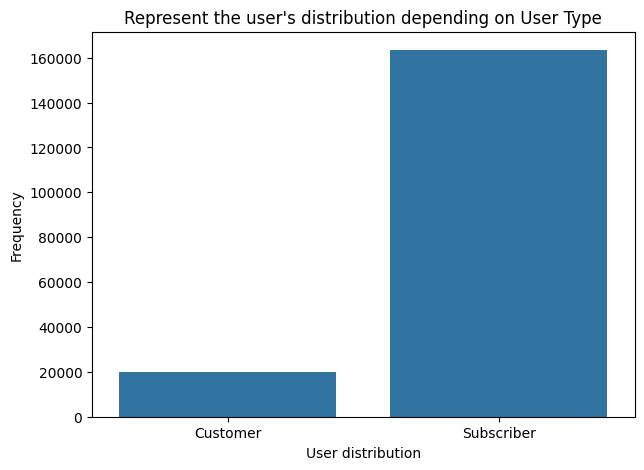

In [38]:
## I will import seaborn library to support me in making visualizations 



display(df['user_type'].value_counts())
plt.figure(figsize = (7,5))

plot = sns.countplot(data=df, x='user_type')

plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on User Type")

plt.show()


## I SEE USER TYPES IS IMBALANCED (SKEWED TOWARD SUBSCRIBER)

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

> ### <mark>Your analsys and exploration here </mark>

bike_share_for_all_trip
No     165869
Yes     17346
Name: count, dtype: int64

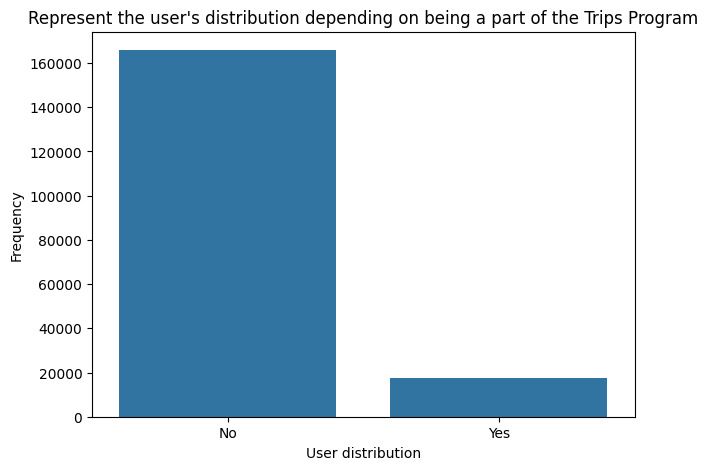

In [39]:
## I will import seaborn library to support me in making visualizations 


display(df['bike_share_for_all_trip'].value_counts())


plt.figure(figsize = (7,5))

plot = sns.countplot(data=df, x='bike_share_for_all_trip')

plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")

# I SEE USERS IMBALACED  PEOPLE NOT PART OF TRIPS PROGRAM
plt.show()

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

> ### <mark>Your analsys and exploration here </mark>

age
Adults          165358
Older people     17857
Children             0
Name: count, dtype: int64

Text(0.5, 1.0, "Represent the user's distribution depending on Users'ages")

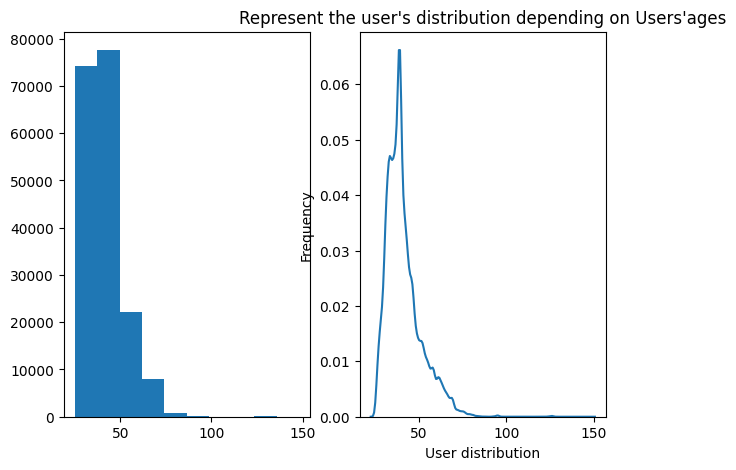

In [40]:
plt.figure(figsize = (7,5))

display(pd.cut(df['age'], bins=[0, 18, 55, float('inf')], labels=['Children', 'Adults', 'Older people']).value_counts())


plt.subplot(1,2,1)
plt.hist(df['age'])
plt.subplot(1,2,2)
sns.kdeplot(df['age'])
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on Users'ages")

# I SEE AGES OF MEMBERS ARE IMBALANCED (RIGHT SKEWED)


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


> ### <mark>Your analsys and exploration here </mark>

<Axes: xlabel='age'>

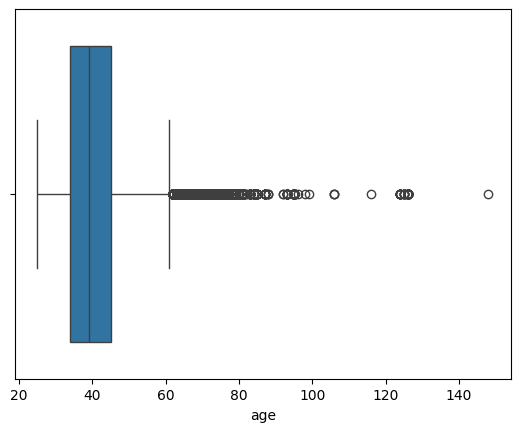

In [41]:
sns.boxplot(df['age'],orient='h')

In [42]:
# SINCE AGE FEATURE IS SKEWED SO BEST OUTLIER DETECTOR IS IQR METHOD 
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
print(( Q3+1.5*IQR))
print(( Q1-1.5*IQR))


outliers=df[(df['age']> Q3+1.5*IQR) | (df['age']< Q1-1.5*IQR)]['age']
display(outliers)



61.5
17.5


5         67
43        67
67        67
117       63
152       62
          ..
183296    67
183304    68
183305    76
183385    81
183388    99
Name: age, Length: 9076, dtype: int16

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

> ### <mark>Your analsys and exploration here </mark>

In [43]:
df['duration_min'].describe()

count    183215.000000
mean         12.098366
std          29.917978
min           1.017000
25%           5.417000
50%           8.567000
75%          13.267000
max        1424.067000
Name: duration_min, dtype: float64

In [44]:
Q1 = df['duration_min'].quantile(0.25)
Q3 = df['duration_min'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[
    (df['duration_min'] > upper_bound) |
    (df['duration_min'] < lower_bound)
]['duration_min']

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)


Q1: 5.417
Q3: 13.267
IQR: 7.85
Lower bound: -6.357999999999999
Upper bound: 25.041999999999998
Number of outliers: 10098
Percentage of outliers: 5.511557459814972


In [45]:
df[df['duration_min'] > upper_bound]['duration_min'].describe()

count    10098.000000
mean        61.295700
std        115.030076
min         25.050000
25%         28.483000
50%         34.167000
75%         47.208500
max       1424.067000
Name: duration_min, dtype: float64

<Axes: xlabel='duration_min'>

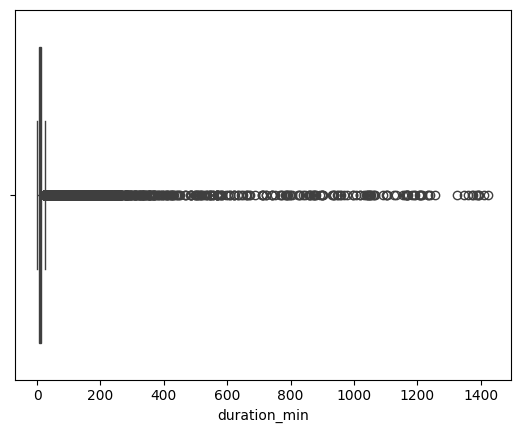

In [46]:
#  DURATION TIME IS RIGHT SKEWED
sns.boxplot(df['duration_min'],orient='h')


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

> ### <mark>Your analsys and exploration here </mark>

<Axes: xlabel='member_gender', ylabel='count'>

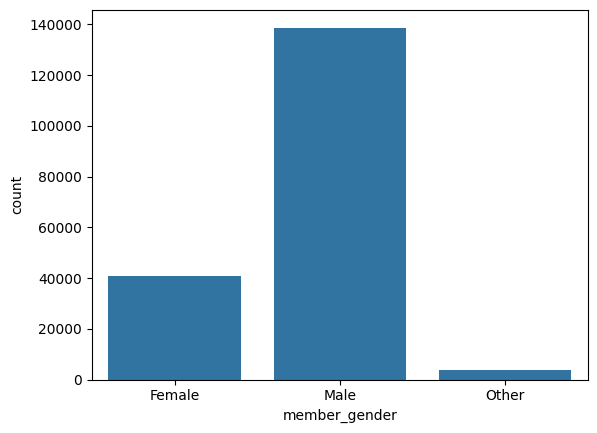

In [47]:
sns.countplot(data=df,x='member_gender')

# Data skewed to male

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

In [48]:
df['duration_hours'].describe()

count    183215.000000
mean          0.201640
std           0.498634
min           0.017000
25%           0.090000
50%           0.143000
75%           0.221000
max          23.734000
Name: duration_hours, dtype: float64

<Axes: xlabel='duration_hours'>

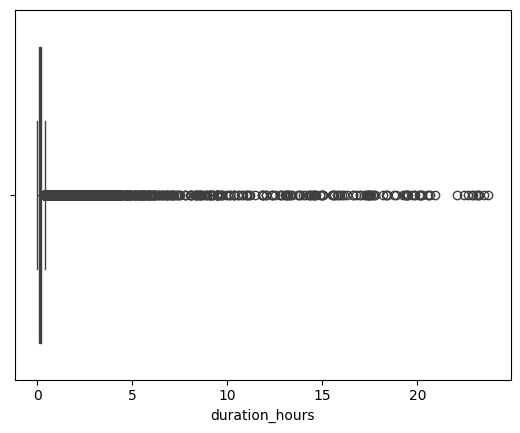

In [49]:
# Make visualization to easy get insight
sns.boxplot(df['duration_hours'],orient='h')

> ### <mark>Your analsys and exploration here </mark>

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [50]:
# Distribution of Age by user types

df.groupby('user_type')['duration_min'].mean()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30816\3290239683.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('user_type')['duration_min'].mean()


user_type
Customer      23.891262
Subscriber    10.669412
Name: duration_min, dtype: float64

# Make visualization to easy get insight


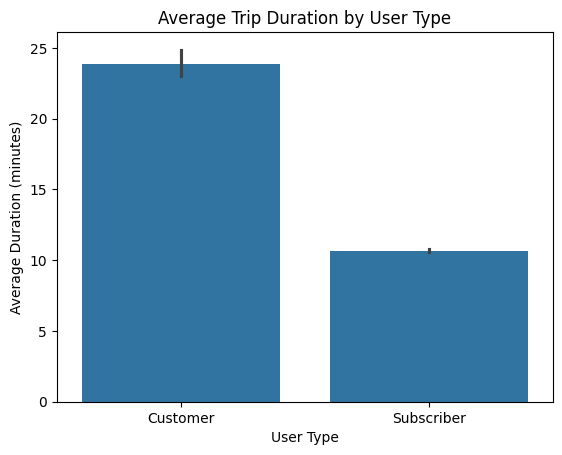

In [51]:
sns.barplot(data=df, x='user_type', y='duration_min')

plt.xlabel('User Type')
plt.ylabel('Average Duration (minutes)')
plt.title('Average Trip Duration by User Type')
plt.show()

> ### <mark>Your analsys and exploration here </mark>

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

Text(0.5, 1.0, 'Average Trip Duration by User Type')

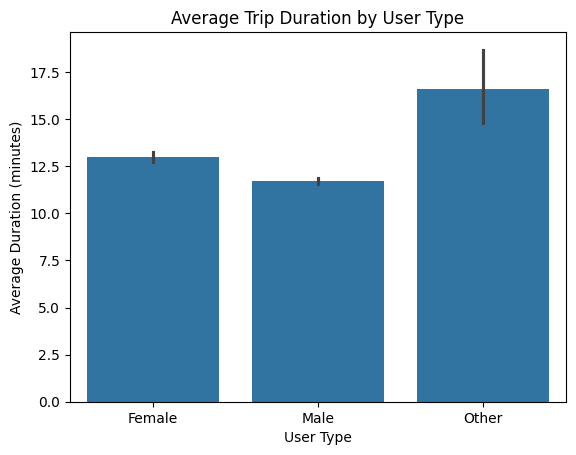

In [52]:
sns.barplot(data=df, x='member_gender', y='duration_min')

plt.xlabel('User Type')
plt.ylabel('Average Duration (minutes)')
plt.title('Average Trip Duration by User Type')


member_gender
Female     529698.390
Male      1626282.859
Other       60620.930
Name: duration_min, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30816\1234673621.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('member_gender')['duration_min'].sum())


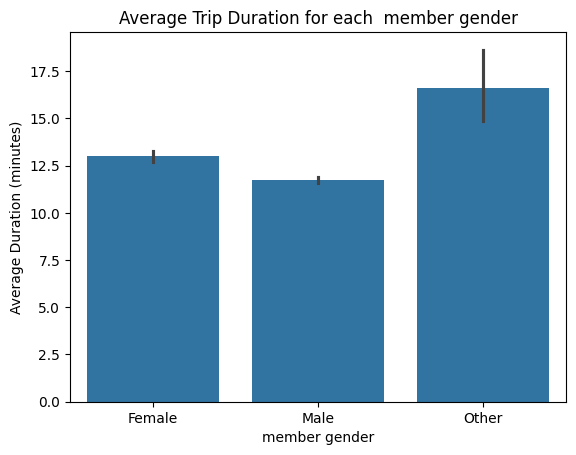

In [53]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender
sns.barplot(data=df, x='member_gender', y='duration_min')

plt.xlabel('member gender')
plt.ylabel('Average Duration (minutes)')
plt.title('Average Trip Duration for each  member gender')

print(df.groupby('member_gender')['duration_min'].sum())

> ### <mark>Your analsys and exploration here </mark>

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

Text(0.5, 1.0, 'Average Trip Duration for each  member gender')

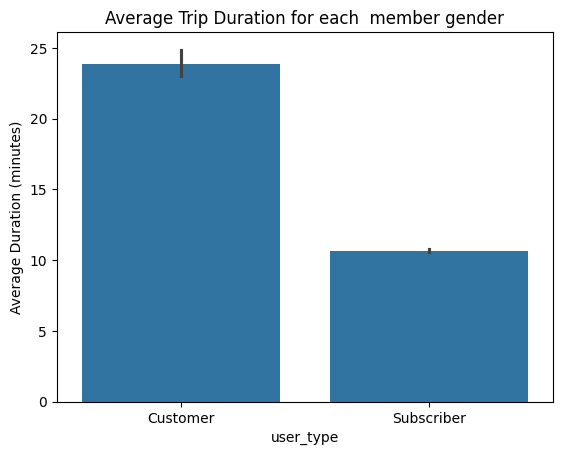

In [54]:

# Make visualization to easy get insight
sns.barplot(data=df, x='user_type', y='duration_min')

plt.xlabel('user_type')
plt.ylabel('Average Duration (minutes)')
plt.title('Average Trip Duration for each  member gender')


In [55]:

print(df.groupby('user_type')['duration_min'].sum())

user_type
Customer       473070.869
Subscriber    1743531.310
Name: duration_min, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30816\2702105598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('user_type')['duration_min'].sum())


> ### <mark>Your analsys and exploration here </mark>

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30816\3208383900.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('user_type')['age'].describe())


               count       mean        std   min   25%   50%   75%    max
user_type                                                                
Customer     19801.0  40.379274   8.698042  25.0  35.0  39.0  43.0  148.0
Subscriber  163414.0  41.184850  10.030655  25.0  34.0  39.0  46.0  126.0


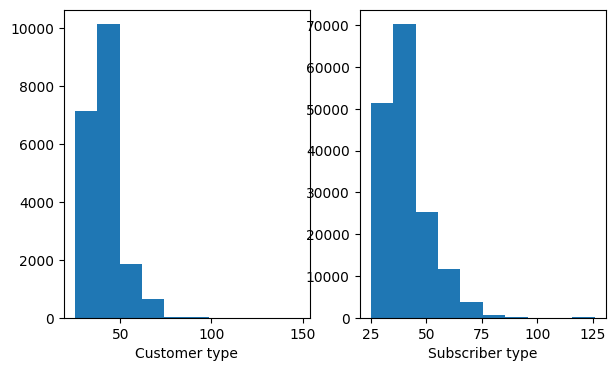

In [56]:

# Make visualization to easy get insight

plt.figure(figsize=(7,4))
for i,user in enumerate(df['user_type'].unique()):
    plt.subplot(1,len(df['user_type'].unique()),i+1)
    plt.hist(df[df['user_type']==user]['age'])
    plt.xlabel(f"{user} type")


print(df.groupby('user_type')['age'].describe())    


> ### <mark>Your analsys and exploration here </mark>

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

                  count       mean        std   min   25%   50%   75%    max
member_gender                                                               
Female          40805.0  40.223698   9.284004  25.0  34.0  38.0  44.0  148.0
Male           138763.0  41.307510  10.049233  25.0  34.0  39.0  46.0  126.0
Other            3647.0  42.897998  10.098447  26.0  36.0  41.0  47.0  116.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30816\2139981025.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('member_gender')['age'].describe())


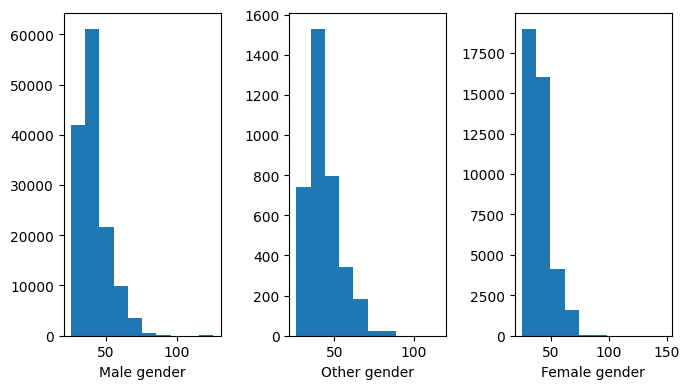

In [57]:
# Make visualization to easy get insight
plt.figure(figsize=(7,4))
for i,gender in enumerate(df['member_gender'].unique()):
    plt.subplot(1,len(df['member_gender'].unique()),i+1)
    plt.hist(df[df['member_gender']==gender]['age'])
    plt.xlabel(f"{gender} gender")

plt.tight_layout()
print(df.groupby('member_gender')['age'].describe())  

> ### <mark>Your analsys and exploration here </mark>

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> customer's trip duration is greater than subscriber's with large difference
> 


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?
missing values in gender and birth year related to class (NO) in by bike_share_for_all_trip

> ....................

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

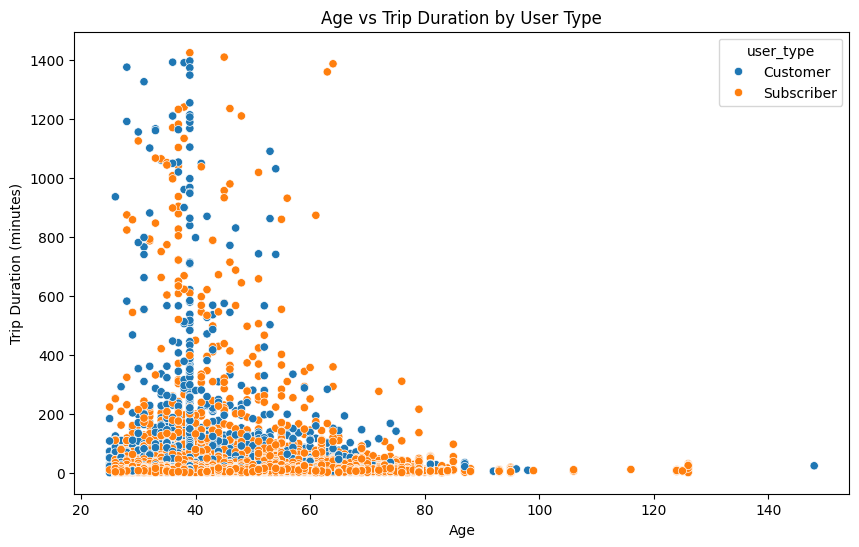

In [58]:
## check your work 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='age',
    y='duration_min',
    hue='user_type'
)

plt.xlabel('Age')
plt.ylabel('Trip Duration (minutes)')
plt.title('Age vs Trip Duration by User Type')
plt.show()



# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

Text(0.5, 1.0, 'Correlation Matrix')

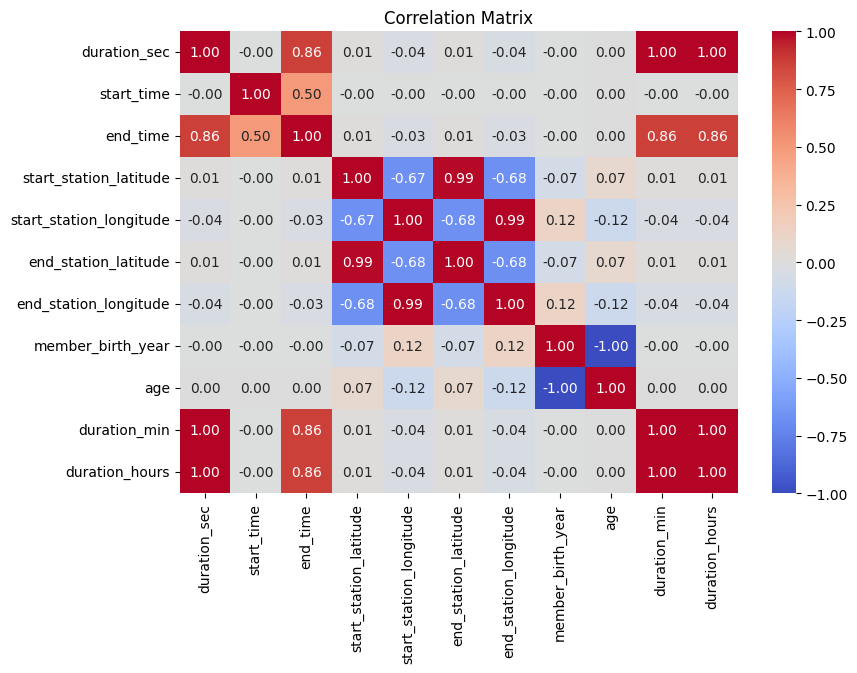

In [59]:
# Make visualization to easy get insight
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')




> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes/hours`)



# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


Text(0.5, 1.0, 'Correlation Matrix')

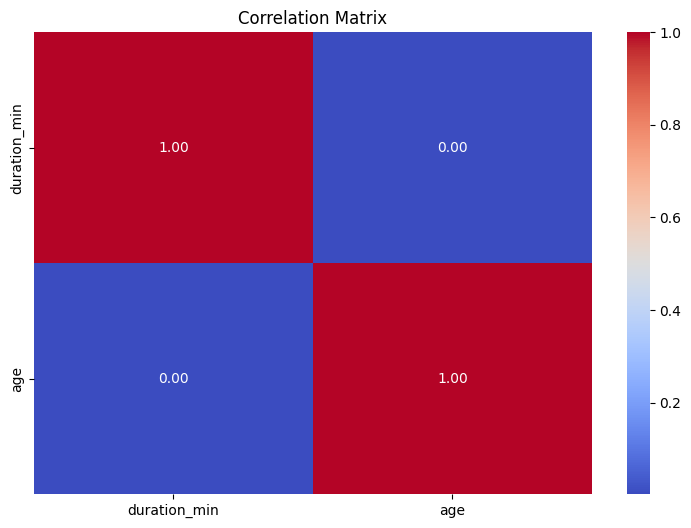

In [60]:
# Make visualization to easy get insight

corr = df[['duration_min','age']].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')


> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- 




- 




# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


In [61]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight



'""This time I will use heatmap  to explain how Correlation between data_stat variables\n\nin the dataset in more clear and specific percentage'

> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- Most users were Male.


- 

- 

- 



## limitation 
example
- We got missing data which we fix some of them .

- 
